In [1]:
import pathlib

import xarray as xr

In [2]:
l1g_path = pathlib.Path("/work/scratch-nopw2/wkjones/EUM_L1g/")

In [3]:
tracking_ds = xr.open_dataset(
    l1g_path/"detected_dccs_L1g_S20240818_000000_E20240819_0000.nc"
)

/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'cfradial1' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'datamet' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'furuno' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gamic' loading failed:
No module named 'xarray.core.merge'
 

In [4]:
tracking_ds

<xarray.Dataset> Size: 730MB
Dimensions:            (latitude: 880, longitude: 1440, time: 48)
Coordinates:
  * latitude           (latitude) float64 7kB 31.98 31.93 ... -11.93 -11.98
  * longitude          (longitude) float64 12kB -71.98 -71.92 ... -0.075 -0.025
  * time               (time) datetime64[ns] 384B 2024-08-18 ... 2024-08-18T2...
Data variables:
    core_label         (time, latitude, longitude) int32 243MB ...
    thick_anvil_label  (time, latitude, longitude) int32 243MB ...
    thin_anvil_label   (time, latitude, longitude) int32 243MB ...

In [5]:
from pystac_client import Client

In [6]:
catalog_url = 'https://catalog.maap.eo.esa.int/catalogue/'
catalog = Client.open(catalog_url)
EC_COLLECTION = ['EarthCAREL2Validated_MAAP']


In [7]:
search = catalog.search(
    collections=EC_COLLECTION, 
    datetime="2024-08-18",
    bbox=(-72, -12, 0, 32), 
    filter="(productType = 'CPR_FMR_2A') or (productType = 'CPR_CD__2A')",
    method = 'GET', # This is necessary 
)

In [8]:
list(search.items())

[<Item id=ECA_EXBA_CPR_CD__2A_20240818T125448Z_20250904T191435Z_01269E>,
 <Item id=ECA_EXBA_CPR_CD__2A_20240818T042541Z_20250904T191846Z_01264A>,
 <Item id=ECA_EXBA_CPR_FMR_2A_20240818T172044Z_20250904T191759Z_01272D>,
 <Item id=ECA_EXBA_CPR_FMR_2A_20240818T142722Z_20250904T193407Z_01270E>,
 <Item id=ECA_EXBA_CPR_FMR_2A_20240818T125448Z_20250904T191435Z_01269E>,
 <Item id=ECA_EXBA_CPR_CD__2A_20240818T055815Z_20250904T193545Z_01265A>,
 <Item id=ECA_EXBA_CPR_CD__2A_20240818T141536Z_20250904T193555Z_01270D>,
 <Item id=ECA_EXBA_CPR_CD__2A_20240818T025306Z_20250904T192635Z_01263A>,
 <Item id=ECA_EXBA_CPR_CD__2A_20240818T060951Z_20250904T193115Z_01265B>,
 <Item id=ECA_EXBA_CPR_FMR_2A_20240818T042541Z_20250904T191846Z_01264A>,
 <Item id=ECA_EXBA_CPR_FMR_2A_20240818T030442Z_20250904T191801Z_01263B>,
 <Item id=ECA_EXBA_CPR_FMR_2A_20240818T055815Z_20250904T193545Z_01265A>,
 <Item id=ECA_EXBA_CPR_FMR_2A_20240818T043717Z_20250904T191917Z_01264B>,
 <Item id=ECA_EXBA_CPR_FMR_2A_20240818T141536Z_2025

In [9]:
list(search.items())[0]

<Item id=ECA_EXBA_CPR_CD__2A_20240818T125448Z_20250904T191435Z_01269E>

In [10]:
import pandas as pd

In [11]:
df = pd.DataFrame(
    data={"stac":list(search.items())}
)

In [12]:
df["granule"] = [f.id[-6:] for f in df.stac]
df["product"] = [f.id[9:19] for f in df.stac]
df["date"] = [pd.to_datetime(f.id[20:35], format="%Y%m%dT%H%M%S") for f in df.stac]

In [13]:
df.sort_values(["product", "date"])

,stac,granule,product,date
7,<Item id=ECA_EXBA_CPR_CD__2A_20240818T025306Z_...,01263A,CPR_CD__2A,2024-08-18 02:53:06
14,<Item id=ECA_EXBA_CPR_CD__2A_20240818T030442Z_...,01263B,CPR_CD__2A,2024-08-18 03:04:42
1,<Item id=ECA_EXBA_CPR_CD__2A_20240818T042541Z_...,01264A,CPR_CD__2A,2024-08-18 04:25:41
15,<Item id=ECA_EXBA_CPR_CD__2A_20240818T043717Z_...,01264B,CPR_CD__2A,2024-08-18 04:37:17
5,<Item id=ECA_EXBA_CPR_CD__2A_20240818T055815Z_...,01265A,CPR_CD__2A,2024-08-18 05:58:15
8,<Item id=ECA_EXBA_CPR_CD__2A_20240818T060951Z_...,01265B,CPR_CD__2A,2024-08-18 06:09:51
17,<Item id=ECA_EXBA_CPR_CD__2A_20240818T124301Z_...,01269D,CPR_CD__2A,2024-08-18 12:43:01
0,<Item id=ECA_EXBA_CPR_CD__2A_20240818T125448Z_...,01269E,CPR_CD__2A,2024-08-18 12:54:48
6,<Item id=ECA_EXBA_CPR_CD__2A_20240818T141536Z_...,01270D,CPR_CD__2A,2024-08-18 14:15:36
23,<Item id=ECA_EXBA_CPR_CD__2A_20240818T142722Z_...,01270E,CPR_CD__2A,2024-08-18 14:27:22


In [14]:
for granule, dfg in df.groupby("granule"):
    break

In [15]:
dfg

,stac,granule,product,date
7,<Item id=ECA_EXBA_CPR_CD__2A_20240818T025306Z_...,01263A,CPR_CD__2A,2024-08-18 02:53:06
21,<Item id=ECA_EXBA_CPR_FMR_2A_20240818T025306Z_...,01263A,CPR_FMR_2A,2024-08-18 02:53:06


In [16]:
from contextlib import contextmanager

@contextmanager
def read_ec_file(filename):
    try:
        f = fs.open(filename)
        ds = xr.open_dataset(
            f, 
            engine="h5netcdf", 
            **io_params["h5py_params"],  
            group="ScienceData"
        )
        yield ds
    finally:
        f.close()
        ds.close()

def select_vars(ds, data_vars):
    return ds.set_coords(["time", "latitude", "longitude", "height"])[data_vars]


In [17]:
for granule, dfg in df.groupby("granule"):
    if len(dfg) == 2:
        break

In [18]:
dfg.stac.tolist()[0].assets.get('enclosure_h5').href

'https://catalog.maap.eo.esa.int/data/earthcare-pdgs-01/EarthCARE/CPR_CD__2A/BA/2024/08/18/ECA_EXBA_CPR_CD__2A_20240818T025306Z_20250904T192635Z_01263A/ECA_EXBA_CPR_CD__2A_20240818T025306Z_20250904T192635Z_01263A/ECA_EXBA_CPR_CD__2A_20240818T025306Z_20250904T192635Z_01263A.h5'

In [19]:
import requests
import fsspec

CREDENTIALS_FILE = (pathlib.Path.home() / "credentials.txt" ).resolve()   # Insert the .txt path
io_params = {
    "fsspec_params": {
        "cache_type": "blockcache",
        "block_size": 8 * 1024 * 1024
    },
    "h5py_params": {
        "driver_kwds": {
            "rdcc_nbytes": 8 * 1024 * 1024
        }
    }
}

def load_credentials(file_path=CREDENTIALS_FILE):
    """Read key-value pairs from a credentials file into a dictionary."""
    creds = {}
    if not file_path.exists():
        raise FileNotFoundError(f"Credentials file not found: {file_path}")
    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if "=" not in line:
                continue
            key, value = line.split("=", 1)
            creds[key.strip()] = value.strip()
    return creds


# --- ESA MAAP API ---

def get_token():
    """Use OFFLINE_TOKEN to fetch a short-lived access token."""
    creds = load_credentials()

    OFFLINE_TOKEN = creds.get("OFFLINE_TOKEN")
    CLIENT_ID = creds.get("CLIENT_ID")
    CLIENT_SECRET = creds.get("CLIENT_SECRET")
    # print(CLIENT_SECRET)

    if not all([OFFLINE_TOKEN, CLIENT_ID, CLIENT_SECRET]):
        raise ValueError("Missing OFFLINE_TOKEN, CLIENT_ID, or CLIENT_SECRET in credentials file")

    url = "https://iam.maap.eo.esa.int/realms/esa-maap/protocol/openid-connect/token"
    data = {
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET,
        "grant_type": "refresh_token",
        "refresh_token": OFFLINE_TOKEN,
        "scope": "offline_access openid"
    }

    response = requests.post(url, data=data)
    response.raise_for_status()

    response_json = response.json()
    access_token = response_json.get('access_token')

    if not access_token:
        raise RuntimeError("Failed to retrieve access token from IAM response")

    return access_token

token = get_token()
fs = fsspec.filesystem(
    "https", 
    headers={"Authorization": f"Bearer {token}"}, 
    **io_params["fsspec_params"], 
)

In [20]:
product_vars = dict(
    CPR_CD__2A=[
        "doppler_velocity_best_estimate", 
        "sedimentation_velocity_best_estimate", 
        "spectrum_width_integrated", 
    ], 
    CPR_FMR_2A=[
        "quality_status", 
        "reflectivity_corrected", 
        "multiple_scattering_status", 
    ], 
)

In [21]:
import numpy as np

from collections import defaultdict

In [22]:
def regrid_dataset(ds, new_coord_values):
    new_ds = xr.Dataset(coords=ds.coords)
    dim = "CPR_height"
    coord = "height"
    new_ds[coord] = (dim,), new_coord_values
    for var in ds.data_vars:
        if dim in ds[var].dims:
            new_ds[var] = ds[var].dims, stratify.interpolate(
                new_ds[coord].values,
                ds[coord].fillna(-np.inf).values,
                ds[var].values,
                axis=ds[var].dims.index(dim),
            )
    return new_ds

In [23]:
import stratify

regridded_datasets = defaultdict(dict)

for granule, dfg in df.groupby("granule"):
    print(granule)
    if len(dfg) == len(product_vars):
        for idx, row in dfg.iterrows():
            with read_ec_file(row["stac"].assets.get('enclosure_h5').href) as ds:
                ds = select_vars(ds, product_vars[row["product"]])
                # print(
                #     ds.latitude.min().item(), 
                #     ds.latitude.max().item(), 
                #     ds.longitude.min().item(), 
                #     ds.longitude.max().item(), 
                # )
                ds = ds.isel(
                    along_track=np.logical_and.reduce([
                        ds.latitude>=-12,
                        ds.latitude<=32,
                        ds.longitude>=-72,
                        ds.longitude<=0
                    ])
                )
                # print(ds.along_track.size)
                if ds.along_track.size > 0:
                    ds.load()
                    regridded_datasets[granule][row["product"]] = (
                        regrid_dataset(ds, np.arange(50, 2e4, 100)[::-1]).swap_dims(CPR_height="height")
                    )
                

01263A
01263B
01264A
01264B
01265A
01265B
01269D
01269E
01270D
01270E
01271D
01271E
01272D


In [24]:
regridded_datasets

defaultdict(dict,
            {'01263A': {'CPR_CD__2A': <xarray.Dataset> Size: 9MB
              Dimensions:                               (along_track: 3749, height: 200)
              Coordinates:
                  time                                  (along_track) datetime64[ns] 30kB 2...
                  latitude                              (along_track) float64 30kB -12.0 .....
                  longitude                             (along_track) float64 30kB -12.01 ....
                * height                                (height) float64 2kB 1.995e+04 ... ...
              Dimensions without coordinates: along_track
              Data variables:
                  doppler_velocity_best_estimate        (along_track, height) float32 3MB n...
                  sedimentation_velocity_best_estimate  (along_track, height) float32 3MB n...
                  spectrum_width_integrated             (along_track, height) float32 3MB n...,
              'CPR_FMR_2A': <xarray.Dataset> Si

In [25]:
fmr_ds = xr.concat([v["CPR_FMR_2A"] for k,v in regridded_datasets.items()], dim="along_track")
cd_ds = xr.concat([v["CPR_CD__2A"] for k,v in regridded_datasets.items()], dim="along_track")

In [26]:
import matplotlib.pyplot as plt

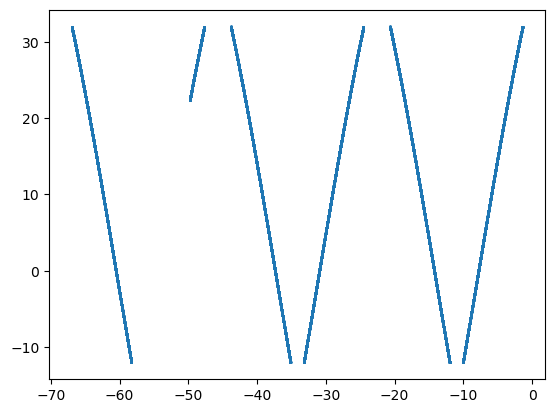

In [27]:
plt.scatter(fmr_ds.longitude, fmr_ds.latitude, s=1)

In [28]:
import os
os.environ["IPFS_GATEWAY"] = "https://ipfs.orcestra-campaign.org"